In [1]:
import numpy as np
import scipy.stats as stats
import pylab as plt 
from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans
from sklearn import preprocessing
from decimal import Decimal

In [2]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [3]:
data

array([['GRB250424A', 'GRB250421A', 'GRB250416C', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['None', 'GRB250421443', 'None', ..., 'None', 'None', 'None'],
       ['6:52:13.431', '10:38:30.832', '17:53:59', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['-999', '10.2400', '-999', ..., '3.1360', '208.5760', '5.6960'],
       ['False', 'True', 'False', ..., 'False', 'False', 'False'],
       ['60789.28626656', '60786.44341241', '60781.74582176', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      dtype='<U14')

In [4]:
names


array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [5]:
def clean_data(name1 , name2):
    #tovo dove si trovano name1 e name2 nell'array data (a quale colonna corrispondono)
    A = np.where(names == name1)[0][0]
    B = np.where(names == name2)[0][0]
    
    #pulisco name1
    name1_raw = data[A][data[A] != '-999']
    name2_raw = data[B][data[A] != '-999']
    
    #converto ad array
    float_name1 = np.asfarray(name1_raw ,dtype = float)
    float_name2 = np.asfarray(name2_raw ,dtype = float)
    
    #pulisco name2
    new_name2 = float_name2[float_name2 != -999]
    new_name1 = float_name1[float_name2 != -999]
    
    return [new_name1 , new_name2]


#here is shown an example on how to use this function:
#  time = clean_data('T90' , 'fluence')[0]
#  fluence = clean_data('T90' , 'fluence')[1]
#  plt.scatter(new_time,new_fluence)
#  plt.show()

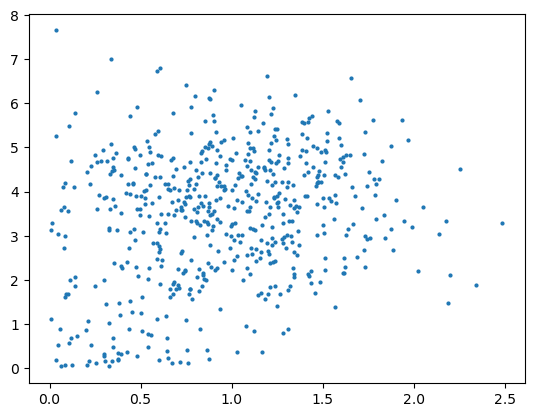

In [6]:
time = clean_data('T90' , 'redshift')[0]
redshift = clean_data('T90' , 'redshift')[1]

plt.scatter(np.log(redshift + 1), np.log(time + 1), s=4)
#plt.ylim(0 , 10)

In [7]:
# Compute the Mean-shift clustering
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn import preprocessing


scaler = preprocessing.StandardScaler()

bandwidth =   1#estimate_bandwidth([mjd ,redshift]) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform([np.log(redshift + 1),np.log(time + 1)]))

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\sklearn\cluster\_mean_shift.py:246: UserWarning: Binning data failed with provided bin_size=1.000000, using data points as seeds.
  warnings.warn(


MeanShift(bandwidth=1, bin_seeding=True, cluster_all=False)

In [8]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[0 1]
1
number of estimated clusters : 2


In [15]:
log_redshift = np.log(redshift + 1).reshape(-1,1)
log_time = np.log(time + 1).reshape(-1,1)
X = np.hstack((log_redshift,log_time))

type(np.log(time +1)[0])
np.asfarray(name1_raw ,dtype = float)

numpy.float64

In [17]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');

TypeError: '<=' not supported between instances of 'str' and 'int'

In [ ]:
redshift = clean_data('redshift' , 'decl')[0]
decl= clean_data('redshift' , 'decl')[1]

plt.scatter(decl , np.log(redshift) ,s= 4)

In [ ]:
scaler = preprocessing.StandardScaler()

bandwidth =   1#estimate_bandwidth([mjd ,redshift]) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform([np.log(redshift),decl]))

#obtaining labels
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

In [ ]:
#from sklearn.manifold import Isomap
#2,3,4,5,7,9,10,12,13,15
#data_list = np.array([data[3], data[4], data[6], data[9], data[11], data[12], data[14]])

#data_numbers = data_list.astype(float)
#iso = Isomap(n_neighbors=3, n_components = 2)
#iso.fit(data_numbers)
#X_reduced =  iso.transform(data_numbers)

#visualize the result
#plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha = 0.5)

In [ ]:
time90 = clean_data('T90' , 'fluence')[0]
fluence = clean_data('T90' , 'fluence')[1]

#plt.xlim(-50,1000)
plt.ylim(-0.00001,0.0001)
plt.scatter(np.log(time90) ,fluence  ,s= 4)

In [ ]:
names